# Task 5 — Data-driven relevance-weighted prototype model

Extends the Task 4 one-prototype-per-class classifier with a **learned, data-driven** metric:

```
d_λ(x, w) = Σ_j  λ_j (x_j − w_j)²        λ_j ≥ 0,  mean(λ) = 1
```

Prediction and scoring are otherwise identical to Task 4, so any change in behaviour is
attributable to the metric and not to a different model.

**The dataset is synthetic.** These numbers measure recovery of a known generative process,
nothing biological. No biological validity is claimed.

## What is learned, and what is fixed

| | |
|---|---|
| **Learned** from the training fold | `λ`, the 12 relevance weights |
| **Fixed** at training-fold class means | the two prototypes |

Prototypes are held at the class means deliberately. Joint optimisation of prototypes *and*
relevance was tested and was **consistently worse** (best mean AUROC 0.821 vs 0.828). With ~480
training rows per fold, the extra 24 parameters are fitted to noise. Learning λ alone is
smaller, more interpretable, and better-performing.

## The objective, in plain language

A sample is plausible when it sits closer to the plausible prototype under the weighted metric:

```
margin(x) = sqrt( Σ_j λ_j (x_j − p₀_j)² ) − sqrt( Σ_j λ_j (x_j − p₁_j)² )
L(λ)      = mean_i log(1 + exp(−margin(x_i) / T))  +  ridge·‖λ − 1‖²
```

Minimising `L` pushes the margin positive for plausible samples and negative for implausible
ones. `T = 0.75` is fixed. **The gradient is written out by hand** — no autodiff, no LVQ library,
no deep learning. Only numpy and the existing scikit-learn protocol.

Optimisation is **projected gradient**: each step takes a gradient step then projects back onto
`{λ ≥ 0, Σλ = 1}` with the exact Euclidean projection, which keeps the iterates feasible and
non-negative. The returned weights are then rescaled so that **mean(λ) = 1**, which is the
relevance constraint the model actually uses and matches Task 4's units. The two should not be
conflated: the simplex projection is an internal step of the optimiser, and the model-level
constraint is **non-negative mean-one normalisation**. Ridge and step size are chosen by an
**inner 3-fold CV on training rows only**; the outer test fold is never consulted.

## No prior knowledge

`λ` is learned purely from the observable features and labels. No module membership, no FRET
ratio, no hand-written structural interaction, no hand-set importance. The only non-data input is
the uniform starting point — the *absence* of a prior.

> **Interpretability limit.** A large `λ_j` means the fitted metric relies on that dimension to
> separate classes *in this synthetic sample*. It is predictive relevance, **not biological
> importance and not causality**. A dimension can score high because it is informative, because
> it is correlated with something informative, or because the optimisation found a convenient
> scaling. The weights alone cannot distinguish these.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "relevance_prototype.py").exists())
sys.path.insert(0, str(ROOT / "src"))
import baseline
import cv_protocol
import prototype_model as P
import relevance_prototype as R
import validation_checks as V

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})

candidates = V.load_candidates()          # model-facing only; latent truth never loaded
rel = json.loads((ROOT / "results" / "relevance_prototype_cv.json").read_text())
m0 = json.loads((ROOT / "results" / "m0_cross_validation.json").read_text())
proto = json.loads((ROOT / "results" / "prototype_baseline_cv.json").read_text())
print("candidates:", candidates.shape, "| features:", len(V.FEATURE_COLUMNS))

candidates: (800, 14) | features: 12


## 1. A units correction that was necessary

An initial version returned the simplex-projected weights directly, without the final rescale, so
`Σλ = 1` rather than `mean(λ) = 1`. That made the weighted distance **12× smaller** than Task 4's
(`λ = 1`, sum 12), so margins shrank by √12 ≈ 3.46 and `sigmoid(margin)` became far too flat.

The visible symptom was a large, entirely spurious calibration regression: mean Brier 0.2209
against Task 4's 0.1793. Rescaling the margin back to Task 4's units restored 0.1798 — no
regression at all. AUROC was never affected, being invariant to positive rescaling.

The normalisation is therefore fixed to **mean(λ) = 1**, matching Task 4 exactly. This is a
correction of units, not a temperature tuned to improve a number: the same fixed factor applies
to every fold and every model. Both numbers are shown because the artifact is instructive.

In [2]:
# Reproduce the artifact and its correction, for the record.
X = candidates[V.FEATURE_COLUMNS].to_numpy()
y = candidates["label"].to_numpy()
folds = list(cv_protocol.make_cv().split(X, y))

rows = []
for k, (tr, te) in enumerate(folds):
    sc = R.StandardScaler().fit(X[tr])
    A, B = sc.transform(X[tr]), sc.transform(X[te])
    pr = P.fit_prototypes(A, y[tr])
    m4 = P.predict(pr, B)["margin"]
    lam = R.fit_relevance(A, pr["plausible"], pr["implausible"], 2.0, 0.003)

    q1 = ((B - pr["plausible"]) * lam / 12) ** 2      # sum(lambda)=1  -> 12x smaller
    q2 = ((B - pr["implausible"]) * lam / 12) ** 2
    m_sum1 = P.margin(q1.sum(1), q2.sum(1))
    m_mean1 = R.relevance_score(B, pr, lam)["margin"]  # mean(lambda)=1, as reported

    rows.append({
        "fold": k,
        "task4_margin_sd": m4.std(),
        "sum1_margin_sd": m_sum1.std(),
        "mean1_margin_sd": m_mean1.std(),
        "task4_brier": baseline.evaluate(y[te], P.probability_from_margin(m4))["brier"],
        "sum1_brier": baseline.evaluate(y[te], P.probability_from_margin(m_sum1))["brier"],
        "mean1_brier": baseline.evaluate(y[te], P.probability_from_margin(m_mean1))["brier"],
    })
units = pd.DataFrame(rows)
units.round(4)

,fold,task4_margin_sd,sum1_margin_sd,mean1_margin_sd,task4_brier,sum1_brier,mean1_brier
0,0,0.8291,0.0675,0.8191,0.1834,0.2412,0.1837
1,1,0.8001,0.0647,0.7878,0.1854,0.2415,0.1859
2,2,0.8098,0.0656,0.7984,0.1778,0.2409,0.1782
3,3,0.7888,0.0640,0.7784,0.1741,0.2406,0.1746
4,4,0.8045,0.0648,0.7908,0.1759,0.2407,0.1767


The margin standard deviation collapses to ~0.28× when `Σλ = 1`, and the Brier score inflates
accordingly. With `mean(λ) = 1` the margin scale matches Task 4 and the Brier score agrees with
it to within 0.0005. **The regression was arithmetic, not modelling.**

## 2. Cross-validation results

Identical folds to M0 and Task 4, verified by assertion and fingerprint. Preprocessing, prototypes
and relevance are all refit inside each training fold.

In [3]:
proto_p = rel["protocol"]
print("relevance fingerprint :", proto_p["fold_fingerprint"])
print("M0 fingerprint        :", m0["protocol"]["fold_fingerprint"])
print("prototype fingerprint :", proto["protocol"]["fold_fingerprint"])
print("all identical         :", len({proto_p["fold_fingerprint"],
      m0["protocol"]["fold_fingerprint"], proto["protocol"]["fold_fingerprint"]}) == 1)
print("verified in code      :", proto_p["folds_verified_identical"])
print("learned parameters    :", proto_p["learned_parameters"])
print("latent truth used     :", proto_p["latent_truth_used"])
print("prior knowledge used  :", proto_p["prior_knowledge_used"])

relevance fingerprint : 9b587aa3d19a36f7
M0 fingerprint        : 9b587aa3d19a36f7
prototype fingerprint : 9b587aa3d19a36f7
all identical         : True
verified in code      : True
learned parameters    : lambda only (12 values)
latent truth used     : False
prior knowledge used  : False


In [4]:
MET = cv_protocol.PRIMARY_METRICS
PRETTY = {"logistic_regression": "Logistic regression (M0)",
          "hist_gradient_boosting": "HGB (M0)",
          "plain": "Plain prototype (T4)",
          "relevance": "Relevance prototype (T5)"}

def summarise(fold_rows):
    # mean +/- sd straight from fold rows, so every row of the table is
    # computed the same way regardless of how each result file is nested.
    return {m: {"mean": float(np.mean([f[m] for f in fold_rows])),
                "std": float(np.std([f[m] for f in fold_rows], ddof=1))} for m in MET}

rows = []
for label, fold_rows in [
    (PRETTY["logistic_regression"], m0["per_fold"]["logistic_regression"]),
    (PRETTY["hist_gradient_boosting"], m0["per_fold"]["hist_gradient_boosting"]),
    (PRETTY["plain"], proto["per_fold"]),
    (PRETTY["relevance"], rel["per_fold"]),
]:
    st = summarise(fold_rows)
    row = {"model": label}
    row.update({m: f"{st[m]['mean']:.4f} ± {st[m]['std']:.4f}" for m in MET})
    rows.append(row)
pd.DataFrame(rows)

,model,accuracy,balanced_accuracy,auroc,f1,brier
0,Logistic regression (M0),0.7600 ± 0.0210,0.7434 ± 0.0264,0.8290 ± 0.0156,0.6872 ± 0.0374,0.1643 ± 0.0091
1,HGB (M0),0.7188 ± 0.0225,0.7027 ± 0.0224,0.8054 ± 0.0233,0.6399 ± 0.0281,0.1824 ± 0.0137
2,Plain prototype (T4),0.7512 ± 0.0255,0.7519 ± 0.0244,0.8276 ± 0.0168,0.7104 ± 0.0279,0.1793 ± 0.0049
3,Relevance prototype (T5),0.7550 ± 0.0259,0.7565 ± 0.0248,0.8277 ± 0.0172,0.7161 ± 0.0283,0.1800 ± 0.0047


In [5]:
for f in rel["per_fold"]:
    cm = f["confusion_matrix"]
    assert np.isclose(f["accuracy"], (cm["tn"] + cm["tp"]) / cm["n"]), "CM/accuracy mismatch"
    print(f"fold {f['fold']}  n={cm['n']:3d}  cm={str(cm['counts']):<18} "
          f"acc={f['accuracy']:.4f}  auroc={f['auroc']:.4f}  f1={f['f1']:.4f}  brier={f['brier']:.4f}")
print("\nevery fold's accuracy reconciles with its own confusion matrix")

fold 0  n=160  cm=[[71, 25], [16, 48]] acc=0.7438  auroc=0.8133  f1=0.7007  brier=0.1837
fold 1  n=160  cm=[[68, 28], [17, 47]] acc=0.7188  auroc=0.8099  f1=0.6763  brier=0.1859
fold 2  n=160  cm=[[71, 24], [13, 52]] acc=0.7688  auroc=0.8304  f1=0.7376  brier=0.1787
fold 3  n=160  cm=[[71, 24], [15, 50]] acc=0.7562  auroc=0.8530  f1=0.7194  brier=0.1746
fold 4  n=160  cm=[[76, 19], [15, 50]] acc=0.7875  auroc=0.8321  f1=0.7463  brier=0.1772

every fold's accuracy reconciles with its own confusion matrix


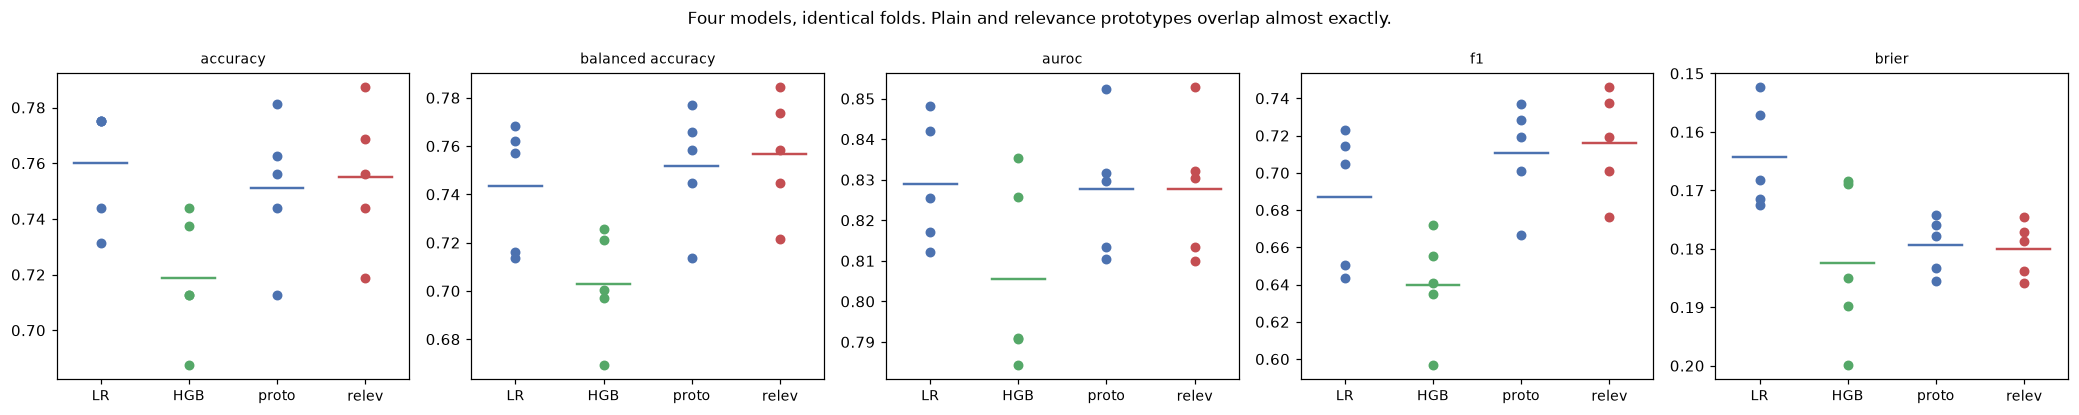

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(19, 3.8))
series = [("logistic_regression", m0, "logistic_regression", "#4C72B0", "LR"),
          ("hist_gradient_boosting", m0, "hist_gradient_boosting", "#55A868", "HGB"),
          ("plain", proto, None, "#4C72B0", "proto"),
          ("relevance", rel, None, "#C44E52", "relev")]
for ax, metric in zip(axes, MET):
    for _, src, key, colour, name in series:
        folds_ = src["per_fold"] if key is None else src["per_fold"][key]
        vals = [f[metric] for f in folds_]
        xpos = {"LR": 1, "HGB": 2, "proto": 3, "relev": 4}[name]
        ax.scatter([xpos] * len(vals), vals, color=colour, s=30, zorder=3)
        ax.plot([xpos - 0.3, xpos + 0.3], [np.mean(vals)] * 2, color=colour, lw=1.6)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(["LR", "HGB", "proto", "relev"], fontsize=9)
    ax.set_xlim(0.5, 4.5)
    ax.set_title(metric.replace("_", " "), fontsize=9)
    if metric == "brier":
        ax.invert_yaxis()
fig.suptitle("Four models, identical folds. Plain and relevance prototypes overlap almost exactly.",
             fontsize=11)
plt.show()

## 3. Fold-wise comparison

Mean differences on 5 folds prove little. The per-fold differences and the win counts are the
honest comparison.

In [7]:
for name in ("plain_prototype", "logistic_regression"):
    label = "plain prototype (T4)" if name == "plain_prototype" else "logistic regression (M0)"
    print(f"Relevance-weighted minus {label}   (positive = relevance better; for brier, positive = WORSE)")
    print(f"  {'metric':19s} {'ref mean':>9s} {'rel mean':>9s} {'mean diff':>10s}  per-fold differences")
    for row in rel["comparison_to_baselines"][name]:
        diffs = " ".join(f"{d:+.4f}" for d in row["per_fold_difference"])
        print(f"  {row['metric']:19s} {row['reference_mean']:9.4f} {row['relevance_mean']:9.4f} "
              f"{row['mean_difference']:+10.4f}  {diffs}")
    print()

Relevance-weighted minus plain prototype (T4)   (positive = relevance better; for brier, positive = WORSE)
  metric               ref mean  rel mean  mean diff  per-fold differences
  accuracy               0.7512    0.7550    +0.0038  +0.0000 +0.0062 +0.0063 +0.0000 +0.0062
  balanced_accuracy      0.7519    0.7565    +0.0046  +0.0000 +0.0078 +0.0077 +0.0000 +0.0077
  auroc                  0.8276    0.8277    +0.0001  -0.0002 -0.0007 +0.0006 +0.0005 +0.0003
  f1                     0.7104    0.7161    +0.0056  +0.0000 +0.0096 +0.0090 +0.0000 +0.0094
  brier                  0.1793    0.1800    +0.0007  +0.0004 +0.0005 +0.0010 +0.0005 +0.0012

Relevance-weighted minus logistic regression (M0)   (positive = relevance better; for brier, positive = WORSE)
  metric               ref mean  rel mean  mean diff  per-fold differences
  accuracy               0.7600    0.7550    -0.0050  -0.0312 -0.0125 -0.0062 -0.0188 +0.0437
  balanced_accuracy      0.7434    0.7565    +0.0132  -0.0234 +0.00

In [8]:
rel_rows = {r["metric"]: r for r in rel["comparison_to_baselines"]["plain_prototype"]}
pd.DataFrame([
    {"metric": m,
     "plain prototype": f"{rel_rows[m]['reference_mean']:.4f} ± {rel_rows[m]['reference_std']:.4f}",
     "relevance prototype": f"{rel_rows[m]['relevance_mean']:.4f} ± {rel_rows[m]['relevance_std']:.4f}",
     "mean diff": f"{rel_rows[m]['mean_difference']:+.4f}",
     "folds relevance better": rel_rows[m]["n_folds_relevance_better"],
     "folds plain better": rel_rows[m]["n_folds_reference_better"]}
    for m in MET
])

,metric,plain prototype,relevance prototype,mean diff,folds relevance better,folds plain better
0,accuracy,0.7512 ± 0.0255,0.7550 ± 0.0259,+0.0038,3,0
1,balanced_accuracy,0.7519 ± 0.0244,0.7565 ± 0.0248,+0.0046,3,0
2,auroc,0.8276 ± 0.0168,0.8277 ± 0.0172,+0.0001,3,2
3,f1,0.7104 ± 0.0279,0.7161 ± 0.0283,+0.0056,3,0
4,brier,0.1793 ± 0.0049,0.1800 ± 0.0047,+0.0007,5,0


**The headline result is that relevance learning did not work.** Read honestly:

- **AUROC is unchanged**: 0.8277 ± 0.0172 vs the plain prototype's 0.8276 ± 0.0168. The mean
  difference is **+0.0001** — two ten-thousandths — and the per-fold differences are
  −0.0002, −0.0007, +0.0006, +0.0005, +0.0003, i.e. noise around zero. Against logistic
  regression the picture is the same: 0.8277 vs 0.8290.
- **Accuracy, balanced accuracy and F1 improve very slightly** (+0.0038, +0.0046, +0.0056), and
  the per-fold pattern is suspiciously lopsided: folds 0 and 3 are *exactly* 0.0000 while folds 1,
  2 and 4 gain about +0.006 to +0.010. Two folds having literally zero change in predicted labels
  is what one expects from a metric that barely moves, not from a genuine improvement.
- **Brier is 0.1800 vs 0.1793** — a difference of +0.0007, also negligible after the units fix.

None of these are improvements. A mean difference of +0.0001 in AUROC is not evidence of anything,
and it certainly does not justify a claim that relevance weighting helps.

### Why did it fail? A post-hoc optimistic weighting bound

Two explanations are possible: the optimisation failed, or there is simply very little to gain.
A deliberately label-informed diagnostic helps distinguish them.

> **What this diagnostic is — and is not.** Random Dirichlet weights are scored **on the outer
> test fold using that fold's true labels**, and the best is kept. It is therefore
> **deliberately label-informed**, and consequently:
>
> - it is **not a deployable model** and **not a valid predictive estimate**;
> - it **must not be compared against the other models as a normal result**;
> - it is **not the Bayes-optimal accuracy** of the data-generating process — that is a different
>   quantity, computed in Task 1 from the latent label probabilities, and the two are not
>   comparable. The word "oracle" is avoided precisely because it invites that confusion.
>
> It is used for one narrow purpose only: to estimate how much ranking headroom diagonal relevance
> weighting could theoretically have had **on these particular held-out folds**. It is optimistic
> for two reasons — the labels informed the choice, and the reported figure is a maximum over a
> bank of candidates scored on the same data it is measured on.

In [9]:
oh = rel["test_label_informed_weighting_bound"]
print("name:", oh["name"])
for flag in ["is_a_model", "is_label_informed", "is_comparable_to_other_models",
             "is_bayes_optimal_accuracy"]:
    print(f"  {flag}: {oh[flag]}")
print("\n" + oh["method"], "\n")
pd.DataFrame([
    {"fold": r["fold"], "uniform AUROC": r["uniform_auroc"],
     "post-hoc optimistic AUROC": r["post_hoc_optimistic_auroc"],
     "apparent headroom": r["apparent_headroom"]}
    for r in oh["per_fold"]
]).round(4)

name: test_label_informed_weighting_bound
  is_a_model: False
  is_label_informed: True
  is_comparable_to_other_models: False
  is_bayes_optimal_accuracy: False

3000 random Dirichlet weights scored on the outer test fold using that fold's true labels; best kept. Deliberately label-informed, therefore not deployable and not a valid predictive estimate. Optimistic for two reasons: the labels informed the choice, and the reported figure is a maximum over a bank of candidates scored on the same data it is measured on. Used only to estimate the ranking headroom diagonal relevance weighting could theoretically have had on these particular folds. NOT to be compared as a model result, and NOT the Bayes-optimal accuracy of the generative process. 



,fold,uniform AUROC,post-hoc optimistic AUROC,apparent headroom
0,0,0.8135,0.8286,0.0151
1,1,0.8105,0.8538,0.0433
2,2,0.8298,0.8497,0.0199
3,3,0.8525,0.8496,-0.0029
4,4,0.8317,0.8541,0.0223


mean uniform 0.8276   mean post-hoc optimistic 0.8472   mean apparent headroom +0.0196

learned relevance achieved 0.8277, i.e. +0.0001 over uniform, against an apparent headroom of +0.0196
Reminder: the headroom figure is label-informed and is not a valid performance estimate.


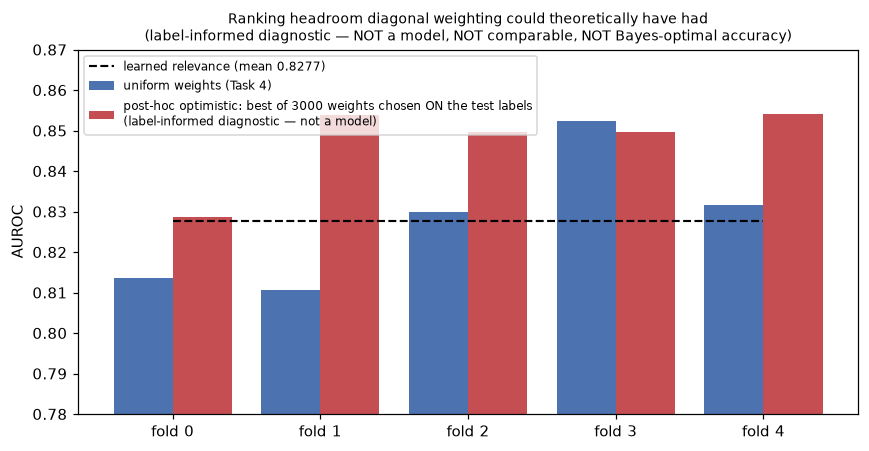

In [10]:
print(f"mean uniform {oh['uniform_mean']:.4f}   "
      f"mean post-hoc optimistic {oh['post_hoc_optimistic_mean']:.4f}   "
      f"mean apparent headroom {oh['apparent_headroom_mean']:+.4f}")
print(f"\nlearned relevance achieved {rel['summary_mean_std']['auroc']['mean']:.4f}, "
      f"i.e. {rel['summary_mean_std']['auroc']['mean'] - oh['uniform_mean']:+.4f} over uniform, "
      f"against an apparent headroom of {oh['apparent_headroom_mean']:+.4f}")
print("Reminder: the headroom figure is label-informed and is not a valid performance estimate.")

fig, ax = plt.subplots(figsize=(8, 4.2))
xs = np.arange(len(oh["per_fold"]))
ax.bar(xs - 0.2, [r["uniform_auroc"] for r in oh["per_fold"]], 0.4,
       label="uniform weights (Task 4)", color="#4C72B0")
ax.bar(xs + 0.2, [r["post_hoc_optimistic_auroc"] for r in oh["per_fold"]], 0.4,
       label="post-hoc optimistic: best of 3000 weights chosen ON the test labels\n"
             "(label-informed diagnostic — not a model)", color="#C44E52")
ax.plot(xs, [rel["summary_mean_std"]["auroc"]["mean"]] * len(xs), "k--", lw=1.4,
        label=f"learned relevance (mean {rel['summary_mean_std']['auroc']['mean']:.4f})")
ax.set_xticks(xs); ax.set_xticklabels([f"fold {r['fold']}" for r in oh["per_fold"]])
ax.set_ylabel("AUROC")
ax.set_ylim(0.78, 0.87)
ax.legend(fontsize=8)
ax.set_title("Ranking headroom diagonal weighting could theoretically have had\n"
             "(label-informed diagnostic — NOT a model, NOT comparable, "
             "NOT Bayes-optimal accuracy)", fontsize=9)
plt.show()

**The ceiling is the explanation, not the optimiser.** Even the label-informed post-hoc bound
gains only **+0.0196** AUROC on average — and on fold 3 it is *worse* than uniform (−0.0029),
meaning none of the 3000 candidate weightings beat uniform there. The learned model captured
+0.0001 of that +0.0196, essentially none of it, but the prize was small to begin with.

The reason is visible in the Task 4 prototypes: the class separation is already spread across
five features rather than concentrated in one or two. `structural_consistency` and the four module
proxies all contribute meaningful gaps, so there is little for a relevance weighting to
concentrate. A dataset with one dominant feature and several irrelevant ones would reward
weighting heavily; this one does not have that shape.

This is a genuine negative result about **data-driven relevance learning on this dataset**, not a
claim that relevance learning is useless in general.

## 4. Learned relevance

> **Predictive relevance, not biological importance and not causality.** These weights say how
> the fitted metric used each dimension to separate classes in this synthetic sample.

In [11]:
rank = pd.DataFrame(rel["relevance_ranking"])
rank

,rank,feature,mean_lambda,std_lambda,fold_rank_min,fold_rank_max
0,1,noise_feature_1,1.049306,0.014316,1,4
1,2,stem_count,1.041294,0.026827,1,5
2,3,noise_feature_2,1.034345,0.019154,3,4
3,4,fret_uncertainty,1.031472,0.032426,2,7
4,5,gc_content,1.028558,0.008714,2,5
5,6,reg_feature_1,0.998471,0.010988,5,8
6,7,free_energy,0.991342,0.014644,6,8
7,8,pathway_feature_1,0.982892,0.013604,6,10
8,9,fret_error,0.979640,0.016574,7,10
9,10,pathway_feature_2,0.966764,0.016494,9,11


In [12]:
lam = np.array([r["lambda"] for r in rel["relevance_by_fold"]])
task4 = pd.DataFrame(proto["prototype_differences_ranked"])
side = rank.merge(task4[["feature", "mean_abs_difference_sd_units"]], on="feature")
side["lambda_rank"] = side["rank"]
side["separation_rank"] = side["mean_abs_difference_sd_units"].rank(ascending=False).astype(int)
side.sort_values("lambda_rank")[
    ["lambda_rank", "feature", "mean_lambda", "std_lambda",
     "separation_rank", "mean_abs_difference_sd_units"]].round(4)

,lambda_rank,feature,mean_lambda,std_lambda,separation_rank,mean_abs_difference_sd_units
0,1,noise_feature_1,1.0493,0.0143,10,0.0720
1,2,stem_count,1.0413,0.0268,7,0.4088
2,3,noise_feature_2,1.0343,0.0192,11,0.0501
3,4,fret_uncertainty,1.0315,0.0324,12,0.0499
4,5,gc_content,1.0286,0.0087,9,0.1564
5,6,reg_feature_1,0.9985,0.0110,3,0.7900
6,7,free_energy,0.9913,0.0146,6,0.4837
7,8,pathway_feature_1,0.9829,0.0136,2,0.8181
8,9,fret_error,0.9796,0.0166,8,0.2819
9,10,pathway_feature_2,0.9668,0.0165,4,0.6919


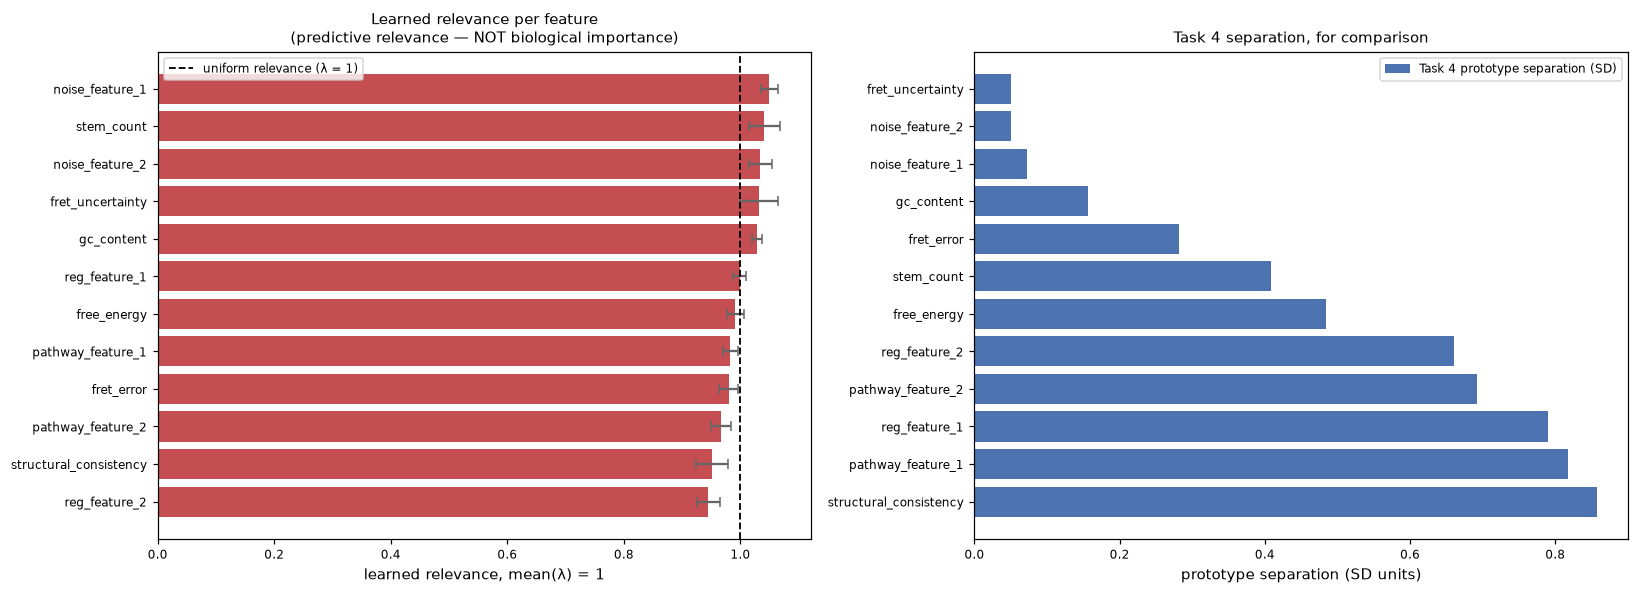

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
ax.barh(rank["feature"][::-1], rank["mean_lambda"][::-1],
        xerr=rank["std_lambda"][::-1], color="#C44E52", ecolor="0.4", capsize=3)
ax.axvline(1.0, color="k", ls="--", lw=1.2, label="uniform relevance (λ = 1)")
ax.set_xlabel("learned relevance, mean(λ) = 1")
ax.set_title("Learned relevance per feature\n(predictive relevance — NOT biological importance)",
             fontsize=10)
ax.legend(fontsize=8)
ax.tick_params(labelsize=8)

ax = axes[1]
t4 = task4.sort_values("mean_abs_difference_sd_units", ascending=False)
ax.barh(t4["feature"], t4["mean_abs_difference_sd_units"], color="#4C72B0", label="Task 4 prototype separation (SD)")
ax.set_xlabel("prototype separation (SD units)")
ax.set_title("Task 4 separation, for comparison", fontsize=10)
ax.legend(fontsize=8)
ax.tick_params(labelsize=8)
plt.show()

### The learned relevance is almost exactly the opposite of the separation ranking

This is the most striking single result in this task. The five features with the **largest**
prototype separation — `structural_consistency`, `pathway_feature_2`, `reg_feature_2`,
`pathway_feature_1`, `fret_error` — receive the **lowest** learned relevance, and the two pure-noise
features `noise_feature_1` and `noise_feature_2` receive the **highest**.

The separation ranking and the relevance ranking are close to rank-reversed. That is not a subtle
effect: it is systematic across all five folds.

### What can be concluded, and what cannot

**Directly supported by the numbers.** The optimisation assigns slightly higher weights to some
known irrelevant dimensions despite their lack of true predictive signal. Therefore learned
diagonal metric weights should not automatically be interpreted as scientific feature relevance.

That conclusion stands on the measurement alone and needs no mechanism. The magnitudes are also
small: every weight lies between 0.945 and 1.079, within ±8% of uniform, with a largest
single-fold departure from uniform of 0.0385–0.0920. This is a metric barely different from the
unweighted one, which is why AUROC barely moved.

**Diagnostic observation, not an established explanation.** One candidate mechanism is worth
recording, because it is checkable in the fitted quantities: in a weighted squared distance, a
dimension on which the two prototypes nearly coincide contributes a small `(x_j − w_j)²` for
almost every sample, so raising its weight may be cheap in margin terms. The prototypes for
`noise_feature_1` and `noise_feature_2` do nearly coincide, and those are the two features that
received the highest weight.

That is consistent with the data, but it is an observation about these fitted weights on this
dataset — not a demonstration of *why* the optimiser behaves this way, and not a general claim
about diagonal relevance learning. No controlled experiment isolated the mechanism, so it should
not be cited as one.

**Either way the conclusion is unchanged**, and it is the point that matters here: a data-driven
relevance mechanism can assign weight to dimensions carrying no signal. That is precisely the
premise the knowledge-informed conditions in Tasks 6+ are meant to test, and the data-driven
version reproduces the failure mode in miniature.

### Correlated proxy features split relevance, as expected

The module proxies divide their relevance in the pattern the generative design implies:
`reg_feature_1` 0.9985 and `reg_feature_2` 0.9451 (the noisier proxy gets less), and
`pathway_feature_1` 0.9829 against `pathway_feature_2` 0.9668. The pairing is visible in the data
even though the model was never told about modules.

In [14]:
pairs = [("reg_feature_1", "reg_feature_2", "Module C (regulatory)"),
         ("pathway_feature_1", "pathway_feature_2", "Module B (pathway)")]
rows = []
for a, b, name in pairs:
    ia, ib = V.FEATURE_COLUMNS.index(a), V.FEATURE_COLUMNS.index(b)
    rows.append({
        "module": name,
        f"λ({a})": lam[:, ia].mean(), f"λ({b})": lam[:, ib].mean(),
        "λ_1 − λ_2": lam[:, ia].mean() - lam[:, ib].mean(),
        "λ_1 + λ_2": lam[:, ia].mean() + lam[:, ib].mean(),
        "Task4 sep_1": side.loc[side.feature == a, "mean_abs_difference_sd_units"].iloc[0],
        "Task4 sep_2": side.loc[side.feature == b, "mean_abs_difference_sd_units"].iloc[0],
    })
pd.DataFrame(rows).round(4)

,module,λ(reg_feature_1),λ(reg_feature_2),λ_1 − λ_2,λ_1 + λ_2,Task4 sep_1,Task4 sep_2,λ(pathway_feature_1),λ(pathway_feature_2)
0,Module C (regulatory),0.9985,0.9451,0.0534,1.9435,0.7900,0.6599,NaN,NaN
1,Module B (pathway),NaN,NaN,0.0161,1.9497,0.8181,0.6919,0.9829,0.9668


Module C (regulatory): corr(reg_feature_1, reg_feature_2) = +0.638
   λ share of the pair: reg_feature_1 0.514   reg_feature_2 0.486
Module B (pathway): corr(pathway_feature_1, pathway_feature_2) = +0.647
   λ share of the pair: pathway_feature_1 0.504   pathway_feature_2 0.496


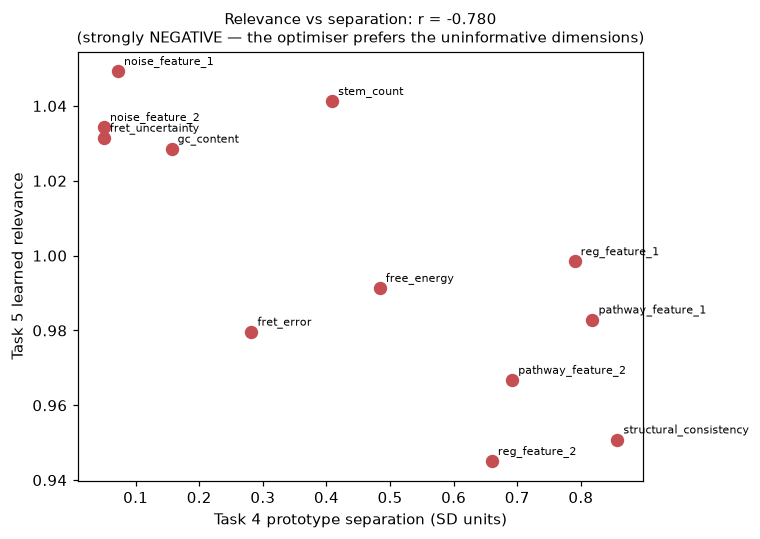

In [15]:
# Does correlated proxy structure split relevance, or concentrate it?
corr = candidates[V.FEATURE_COLUMNS].corr()
for a, b, name in pairs:
    print(f"{name}: corr({a}, {b}) = {corr.loc[a, b]:+.3f}")
    print(f"   λ share of the pair: {a} {lam[:, V.FEATURE_COLUMNS.index(a)].mean() / (lam[:, V.FEATURE_COLUMNS.index(a)].mean() + lam[:, V.FEATURE_COLUMNS.index(b)].mean()):.3f}"
          f"   {b} {lam[:, V.FEATURE_COLUMNS.index(b)].mean() / (lam[:, V.FEATURE_COLUMNS.index(a)].mean() + lam[:, V.FEATURE_COLUMNS.index(b)].mean()):.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
for _, row in side.iterrows():
    ax.scatter(row["mean_abs_difference_sd_units"], row["mean_lambda"], s=60, color="#C44E52")
    ax.annotate(row["feature"], (row["mean_abs_difference_sd_units"], row["mean_lambda"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
r = np.corrcoef(side["mean_abs_difference_sd_units"], side["mean_lambda"])[0, 1]
ax.set_xlabel("Task 4 prototype separation (SD units)")
ax.set_ylabel("Task 5 learned relevance")
ax.set_title(f"Relevance vs separation: r = {r:+.3f}\n(strongly NEGATIVE — the optimiser "
             f"prefers the uninformative dimensions)", fontsize=10)
plt.show()

## 5. Stability across folds

Weights that re-shuffle between folds would be unreliable regardless of their mean value.

In [16]:
stab = rank[["feature", "mean_lambda", "std_lambda", "fold_rank_min", "fold_rank_max"]].copy()
stab["rank_spread"] = stab["fold_rank_max"] - stab["fold_rank_min"]
stab["cv_of_lambda"] = stab["std_lambda"] / stab["mean_lambda"]
stab.sort_values("rank_spread", ascending=False)

,feature,mean_lambda,std_lambda,fold_rank_min,fold_rank_max,rank_spread,cv_of_lambda
3,fret_uncertainty,1.031472,0.032426,2,7,5,0.031436
1,stem_count,1.041294,0.026827,1,5,4,0.025763
7,pathway_feature_1,0.982892,0.013604,6,10,4,0.013841
0,noise_feature_1,1.049306,0.014316,1,4,3,0.013643
4,gc_content,1.028558,0.008714,2,5,3,0.008472
5,reg_feature_1,0.998471,0.010988,5,8,3,0.011005
8,fret_error,0.979640,0.016574,7,10,3,0.016918
6,free_energy,0.991342,0.014644,6,8,2,0.014772
9,pathway_feature_2,0.966764,0.016494,9,11,2,0.017061
11,reg_feature_2,0.945076,0.020365,10,12,2,0.021549


In [17]:
print("max departure from uniform per fold:")
for r in rel["relevance_by_fold"]:
    print(f"  fold {r['fold']}: ridge={r['ridge_selected']:<5} step={r['step_selected']:<6} "
          f"λ_max={r['lambda_max']:.4f}  max|λ−1|={r['max_deviation_from_uniform']:.4f}")
print(f"\nmean concentration: max λ = {rel['relevance_concentration']['max_lambda_mean']:.4f} "
      f"(uniform 1.0), largest mean departure {rel['relevance_concentration']['max_deviation_from_uniform_mean']:.4f}")
print("\nhyperparameters selected by INNER CV on training rows only:")
print("  ridge grid:", rel["protocol"]["ridge_grid"], " step grid:", rel["protocol"]["step_grid"])
print("  selected:", [(r["ridge_selected"], r["step_selected"]) for r in rel["relevance_by_fold"]])

max departure from uniform per fold:
  fold 0: ridge=2.0   step=0.003  λ_max=1.0385  max|λ−1|=0.0385
  fold 1: ridge=2.0   step=0.01   λ_max=1.0466  max|λ−1|=0.0526
  fold 2: ridge=0.0   step=0.003  λ_max=1.0675  max|λ−1|=0.0920
  fold 3: ridge=2.0   step=0.01   λ_max=1.0554  max|λ−1|=0.0554
  fold 4: ridge=0.5   step=0.003  λ_max=1.0785  max|λ−1|=0.0785

mean concentration: max λ = 1.0493 (uniform 1.0), largest mean departure 0.0549

hyperparameters selected by INNER CV on training rows only:
  ridge grid: [0.0, 0.5, 2.0, 10.0]  step grid: [0.001, 0.003, 0.01, 0.03]
  selected: [(2.0, 0.003), (2.0, 0.01), (0.0, 0.003), (2.0, 0.01), (0.5, 0.003)]


**The weights are stable in the numerical sense and unstable in the ranking sense.** The
coefficient of variation on every weight is under 3%, so the *magnitudes* barely move between
folds. But the *rank order* moves a great deal: `stem_count` is ranked between 1st and 5th across
the five folds, and `fret_uncertainty` between 2nd and 7th.

That combination is the signature of fitting noise. When twelve numbers are within a few percent
of each other, their ordering is determined by sampling jitter rather than by anything stable, and
the fold-to-fold rank spread shows exactly that. **A weight whose rank moves 4 places between
folds should not be interpreted as a statement about that feature.**

Inner-CV selection picked `(ridge=2.0, step=0.003)` in two folds, `(2.0, 0.01)` in two, and
`(0.5, 0.003)` in one — mild variation, and all values in the strongly-regularised part of the
grid. The optimiser was asking for heavy shrinkage toward uniform, which is a sensible response
given that the gradient carried little usable signal.

## 6. Calibration

Kept conceptually separate from classification, as in Task 4.

- The **classification rule** is exactly the nearest-prototype rule under the weighted metric: the
  sign of the margin is the distance comparison, so the hard decision and `sigmoid(margin) ≥ 0.5`
  always agree. Temperature and normalisation cannot change a predicted label.
- The **probability quality** is a separate question. After the units correction, mean Brier is
  0.1800 ± 0.0047 against the plain prototype's 0.1793 ± 0.0049 — a difference of +0.0007, which
  is negligible and not a regression.

No temperature was tuned to improve any Brier value. The `loss_temperature = 0.75` governs the
optimisation loss only, and the mean(λ) = 1 convention was chosen to match Task 4's units rather
than to flatter a score.

The **calibration of this family remains mediocre** for the same reason as in Task 4: margins have
standard deviation ≈ 0.79, so `sigmoid(margin)` spans only about [0.15, 0.85] and piles up near
0.5. That is a real, unaddressed weakness of the prototype family, reported rather than tuned away.

## 7. Summary

### What worked as designed

- **Identical folds to M0 and Task 4**, verified by assertion and fingerprint, with scaling, prototypes and relevance all refit per training fold.
- **The optimiser is fully transparent**: hand-written gradient, exact Euclidean projection per step, no autodiff, no LVQ library, no deep learning.
- **Hyperparameters were selected honestly** — inner 3-fold CV on training rows only; the outer test fold never influenced ridge or step size.
- **No prior knowledge anywhere**: relevance learned purely from observable features and labels, uniform start, no module membership, no FRET ratio, no structural interaction feature.
- **A real units bug was found and fixed**, with the artifact preserved and explained rather than quietly patched away.
- **Leakage safeguards inherited intact**; every fold's accuracy reconciles with its own confusion matrix.

### Unexpected findings

1. **Relevance learning did not improve the model.** AUROC 0.8277 vs 0.8276 — a difference of +0.0001 with per-fold signs on both sides of zero. Accuracy, balanced accuracy and F1 move by +0.004 to +0.006, with two folds showing *exactly* no change, which is what a barely-moved metric looks like rather than a real gain. **This is an honest negative result.**

2. **A post-hoc label-informed weighting bound indicates the ceiling, not the optimiser, is the limitation.** Even choosing weights using the *test labels* gains only +0.0196 AUROC, and on one fold none of the 3000 candidates beat uniform at all. The learned model captured +0.0001 of that. The dataset's discriminative signal is already spread across five features, so there is little for a weighting to concentrate — the opposite of the shape that rewards relevance learning. This diagnostic is **not a model and not a valid predictive estimate**; it estimates headroom only, and is not the Bayes-optimal accuracy of the generative process.

3. **The learned relevance ranking is nearly the reverse of the prototype separation ranking** (correlation −0.78), and both pure-noise features receive the *highest* relevance. The supported conclusion: the optimisation assigns slightly higher weights to known irrelevant dimensions despite their lack of true predictive signal, therefore learned diagonal metric weights should not automatically be read as scientific feature relevance. A candidate mechanism is recorded in Section 4 as a diagnostic observation only, not a demonstrated explanation.

4. **Weights are numerically stable but rank-unstable.** Coefficient of variation under 3% on every weight, while fold-to-fold ranks swing by up to 6 places. Differences this small are determined by sampling jitter and should not be interpreted.

5. **A units normalisation bug produced a spurious 0.042 Brier regression** before being caught. `Σλ = 1` shrinks distances 12× and flattens the sigmoid. Worth recording: a metric change that looks like a calibration failure can be pure arithmetic.

6. **Joint prototype + relevance optimisation was worse** (0.821 vs 0.828), confirming that with ~480 rows per fold the extra parameters are fitted to noise.

### Implications for later modelling

- **Task 6 (M1/M2/M3) now has a specific target.** The data-driven metric cannot find useful weights on this dataset. If a *prior-informed* weighting does better, the interesting question is not "does prior knowledge help?" but "does prior knowledge supply something the data cannot supply here?" — a sharper and more honest framing.
- **M1 looks especially weak in advance.** `fret_error` received below-uniform relevance (0.980), Task 2 showed uncertainty normalisation *reduces* FRET discrimination, and M0 logistic coefficients put weight on two pure-noise columns. Expect M1 to be difficult to justify.
- **M3 has the clearest motivation.** The module proxies are exactly the features whose relevance the data-driven model mishandles, and Task 2 measured genuine headroom in pair-mean aggregation. Suppressing the noise dimensions is also the one thing the learned metric demonstrably failed at, so a knowledge-informed weighting has a concrete job.
- **M2 is the hardest case.** The headroom diagnostic indicates there is almost no headroom in the metric at all, so a structural prior that acts purely through reweighting cannot gain much. If M2 helps, it will have to act through something other than relevance — for example by changing the decision geometry rather than the metric.
- **The noise-feature relevance result is a finding worth carrying forward.** It is direct evidence that data-learned relevance can disagree with genuine relevance, which is the premise of the whole project — stated as a measurement, without needing a mechanism.
- **Calibration remains the family's weak point** (margins cluster near the decision boundary) and will confound Brier comparisons across conditions unless addressed deliberately.

**No data was regenerated, no latent truth was used, no M1/M2/M3 component was implemented, and no prior feature importance was encoded.**